In [1]:
import logging

import matplotlib.pyplot as plt
import torch

import specter
from specter import rotations
from specter.fft import fft2
from specter.image import normalize_particles
from specter.imagegenerator import ImageGenerator
from specter.pdb import PDB
from specter.plots import plot3d
from specter.potential import PotentialBuilder
from specter.arrays import radial_profile_2d
from specter.progress import track

%load_ext autoreload
%autoreload 2

In [2]:
specter.set_verbosity(logging.INFO)

## Create 3D scattering potential

In [3]:
# fetch pdb file
pdb_code = "6bdf"
assembly = True  # True: fetches assembly. False: fetches subunit. int: fetches specific assembly #int
pdb = PDB(pdb_code, assembly=True, savefolder="../pdb-data/")
# pdb = PDB("../pdb-data/water_645_coords.pdb")

Assemblies available: 1
6bdf: Fetching default Biological Assembly 1
File already exists: ../pdb-data/6bdf-assembly1.cif, skip fetching.


Extracting atom coordinates and element: 0it [00:00, ?it/s]

In [4]:
# Samples 3D scattering potential onto specified grid
n = 256  # number of pixels per axis
dx = 1  # angstrom, pixel size.
device = "cpu"
pb = PotentialBuilder(n, dx, pdb.atomic_numbers).to(device)

In [5]:
with torch.no_grad():
    V = pb(pdb.coordinates).clone()

Building element ...:   0%|          | 0/4 [00:00<?, ?it/s]

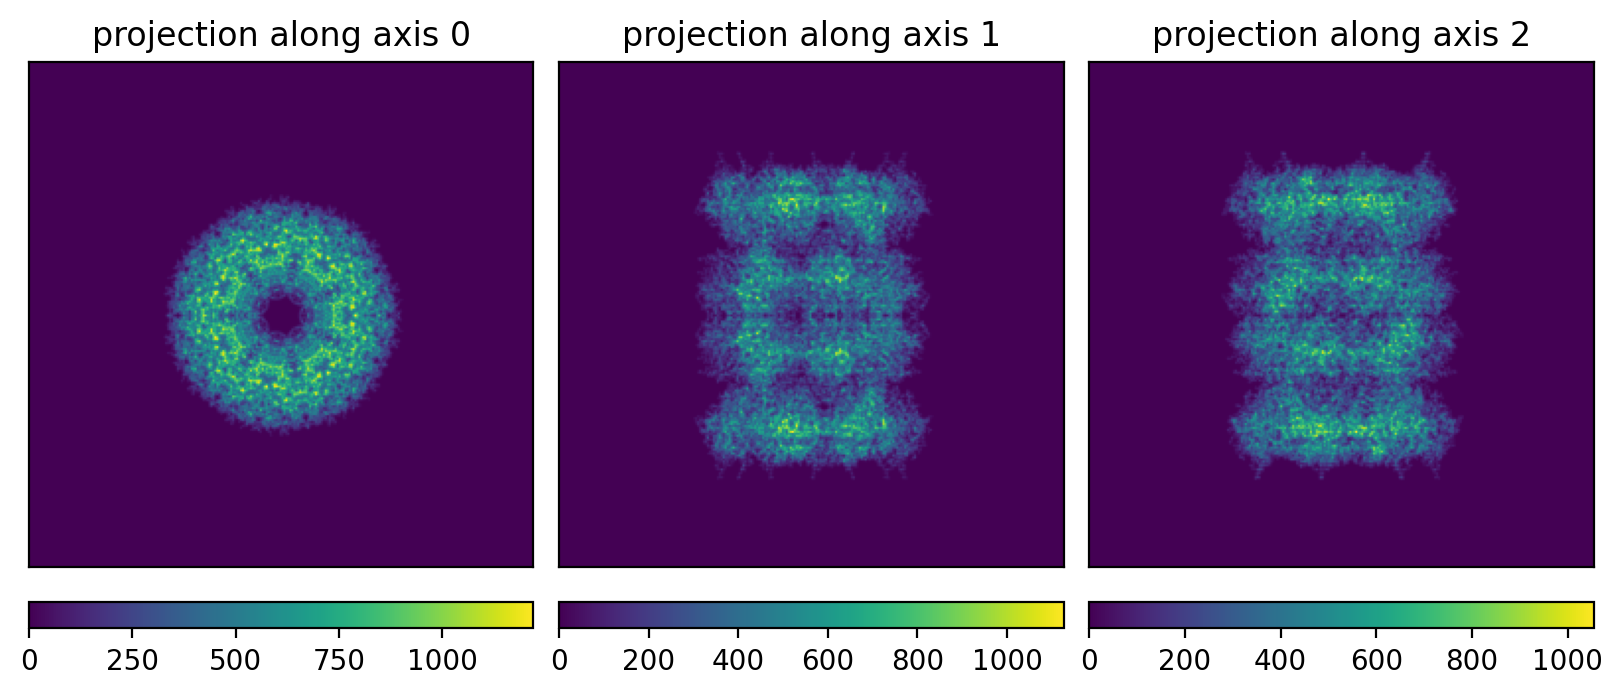

In [6]:
plot3d(V)

## Generate dataset
Here, you can choose to either use random or in-plane rotations, and random or fixed defocus values (comment/uncomment respectively).

In [7]:
n_particles = 20
energy = 300  # keV
dose_per_angstrom = 20  # e-/A^2
Cs = 2e7  # angstrom. Sherical aberration, typical values are 1-3 mm.
alpha = 0.1
num_frames = int(dose_per_angstrom)  # usually ~ 1-2 e-/A^2/frame

In [8]:
# random quaternions
quaternions = rotations.random_quaternion(n_particles)
quaternions.shape

torch.Size([20, 4])

In [9]:
# random defocus
defocus_min = 5000  # angstrom
defocus_max = 15000  # angstrom
defocus_A = torch.rand(n_particles) * (defocus_max - defocus_min) + defocus_min


# Can include 'cs', 'dfu', 'dfv', 'dfang', 'tiltx', 'tilty', 'phaseshift', 'trefoil1, 'trefoil2'
ctf_params = {
    "cs": torch.tensor([Cs] * n_particles),
    "dfu": defocus_A,
}

In [10]:
# random shift. set to 0 for no shifts
shift = 2  # A
rlnOriginXAngst = 2 * (torch.rand(n_particles) - 0.5) * shift
rlnOriginYAngst = 2 * (torch.rand(n_particles) - 0.5) * shift
translations = torch.stack([rlnOriginXAngst, rlnOriginYAngst], dim=-1)
translations.shape

torch.Size([20, 2])

In [11]:
device = "cuda:1"  # choose cpu if you run out of cuda memory.

In [12]:
# Scattering model: 'multislice', 'firstborn', 'projection', 'ctf'
scattering_model = "multislice"

# Aberration model: 'holography' or 'ctf'
aberration_model = "holography"

# Noise model: 'poisson' or None
noise_model = "poisson"
# noise_model = None

# Coincidence radius in angstroms.
# Higher values suppress lower spatial frequencies.
# Set to 0 to recover default Poisson behaviour.
coincidence_radius = 1.8

# Ice model:
#   'random' : fast, worst accuracy
#   'ap'     : alternating projection. moderate speed, low accuracy
#   'gd'     : gradient descent. slow, highest accuracy
#   'mcmc'   : monte carlo markov chain. slowest, medium accuracy, under development.
#   None     : disable ice
ice_model = "gd"
# ice_model = None

ice_thickness = 0  # angstroms, set to 0 for minimum ice thickness = particle box size

crowd_min_distance = pdb.max_diameter  # angstroms, set to None for no crowding
# crowd_min_distance = None

crowd_max_distance_z = None  # if None, defaults to ice_thickness which would result in too many particles above each other.

# pad_fft = False  # True to avoid edge artifacts when if crowd_min_distance is not None
pad_fft = True

detector_model = None
# detector_model = "perfect"  # 'perfect', 'k3_300kv', 'k3_200kv'

model = ImageGenerator(
    V,
    dx,
    quaternions,
    translations,
    ctf_params,
    energy,
    dose_per_angstrom,
    ice_model=ice_model,
    ice_thickness=ice_thickness,
    scattering_model=scattering_model,
    aberration_model=aberration_model,
    noise_model=noise_model,
    klim=None,
    ews_curvature_sign="positive",
    alpha=alpha,
    crowd_min_distance=crowd_min_distance,
    crowd_max_distance_z=crowd_max_distance_z,
    pad_fft=pad_fft,
    detector_model=detector_model,
    verbose=False,
    coincidence_radius=coincidence_radius,
    num_frames=num_frames,
).to(device)

/mnt/cbis/home/e0788253/czii/specter/src/specter/ice/_ap.py:136: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  mdsim_f_radial_avg = torch.load(saved_data_path)


In [1]:
idx = torch.arange(n_particles)
images = []
batchsize = 5  # set higher or lower for faster/slower generation.
with torch.no_grad():
    for i in track(range(0, n_particles, batchsize), description="Generating images"):
        image = model(idx[i : i + batchsize])
        images.append(image.detach().cpu())

images = torch.concat(images, dim=0)
images.shape

The history saving thread hit an unexpected error (OperationalError('attempt to write a readonly database')).History will not be written to the database.


NameError: name 'torch' is not defined

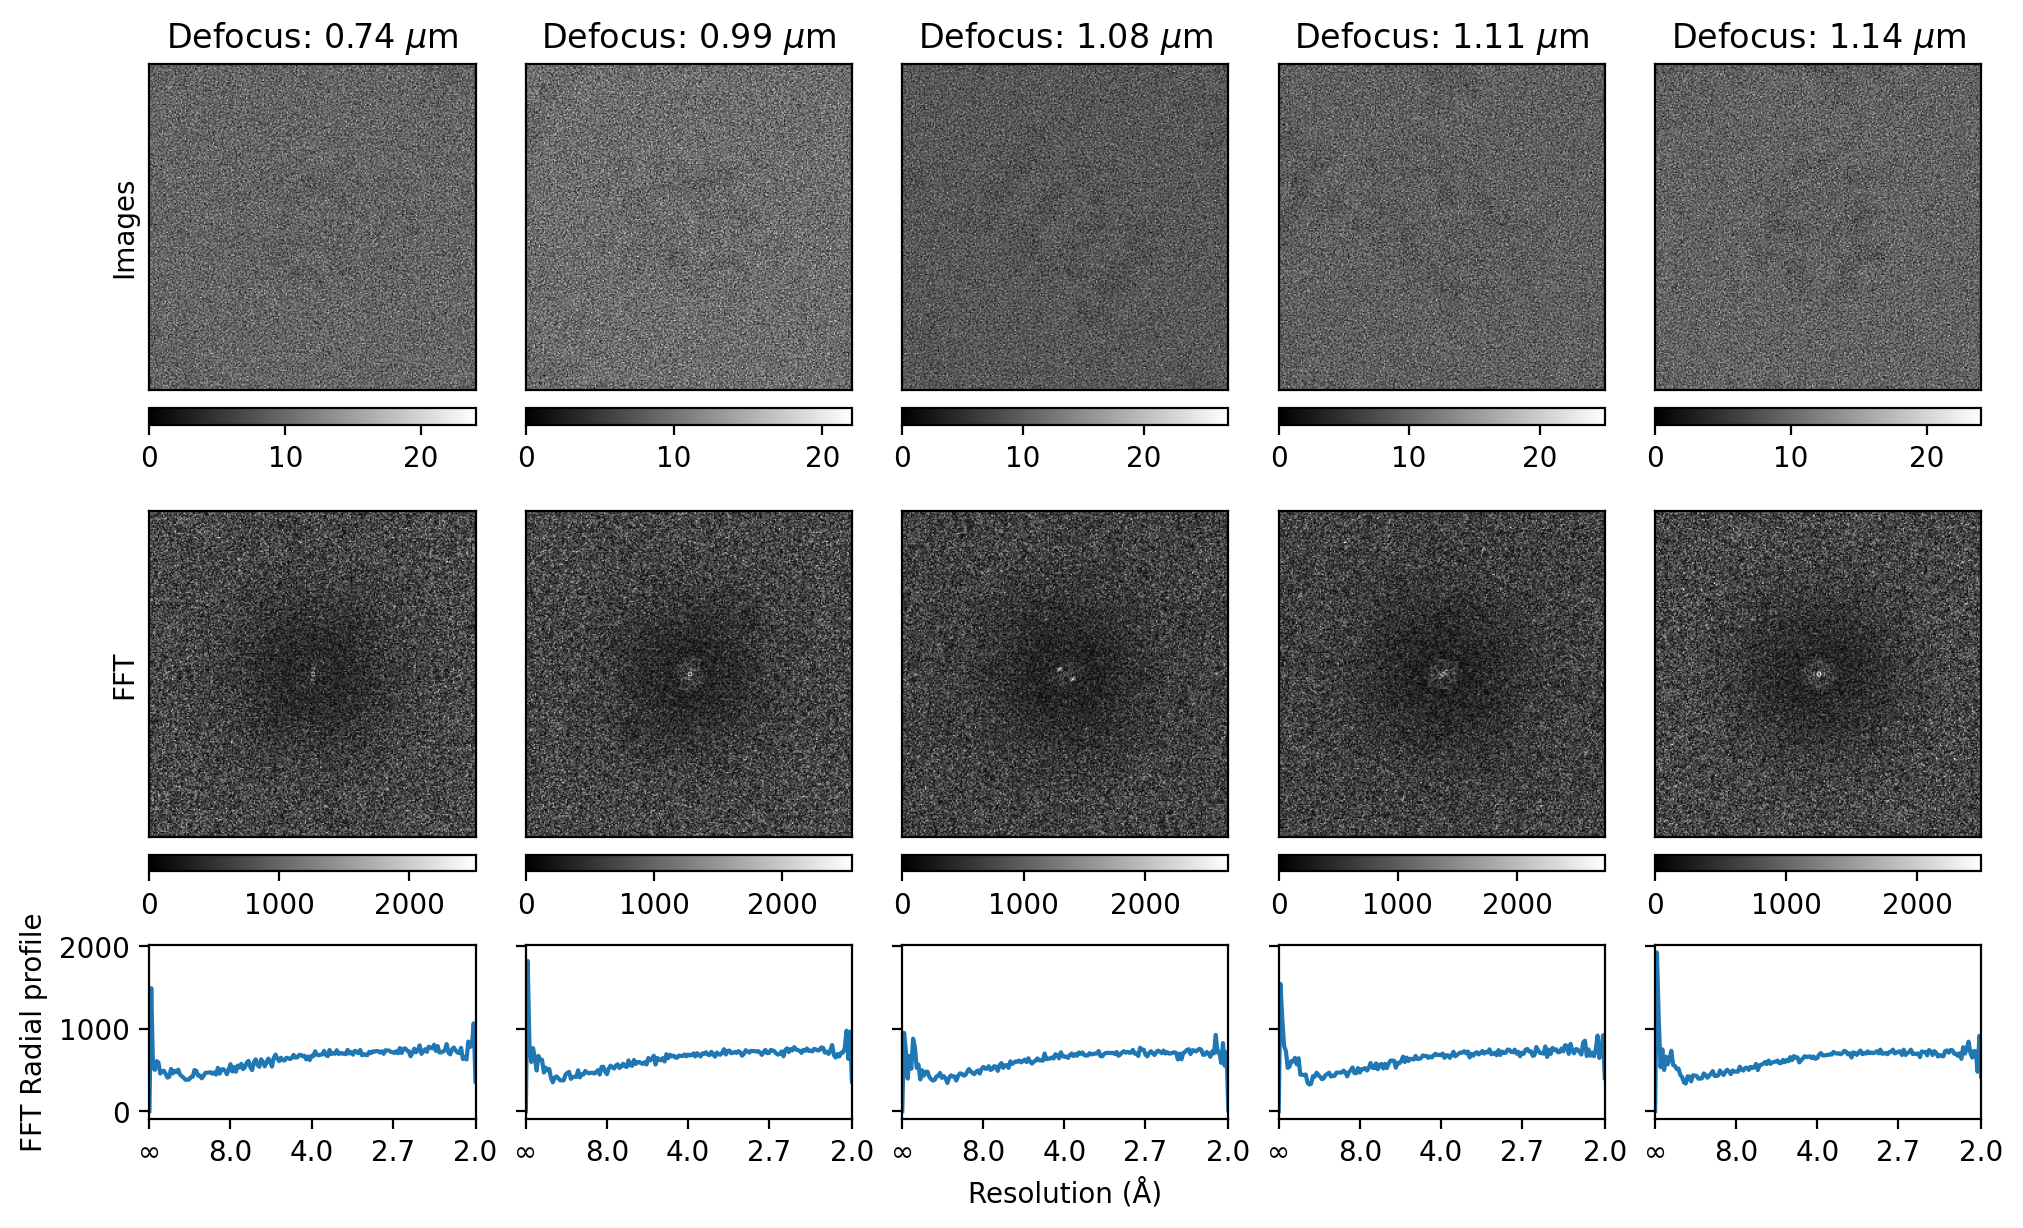

In [14]:
fig, axes = plt.subplots(
    3,
    5,
    dpi=200,
    constrained_layout=True,
    figsize=(10, 6),
    gridspec_kw={"height_ratios": [2, 2, 1]},
)
# after creating the axes, share y across the last row
for ax in axes[2, 1:]:
    ax.sharey(axes[2, 0])
    plt.setp(ax.get_yticklabels(), visible=False)

for i in range(5):
    ax = axes[0, i]
    im = ax.imshow(images[i], cmap="grey")
    ax.set(xticks=[], yticks=[])
    ax.set_title(f"Defocus: {ctf_params['dfu'][i] / 10000:.2f} $\mu$m")
    fig.colorbar(im, ax=ax, location="bottom")

    ax = axes[1, i]
    im = ax.imshow(
        torch.abs(fft2(images[i] - torch.mean(images[i]), shift=True)),
        cmap="grey",
        # vmax=5000,
    )
    ax.set(xticks=[], yticks=[])
    fig.colorbar(im, ax=ax, location="bottom")

    ax = axes[2, i]
    profile = radial_profile_2d(
        torch.abs(fft2(images[i] - torch.mean(images[i]), shift=True))
    )
    n = len(profile)
    ax.plot(profile.numpy() if hasattr(profile, "numpy") else profile)

    # X ticks: 6 ticks from 0 (inf) to n-1 (Nyquist)
    tick_positions = [int(j * (n - 1) / 4) for j in range(5)]
    # Spatial frequency in 1/Å: ranges from 0 to 1/(2*dx)
    # Avoid division by zero at position 0 (inf)
    tick_labels = []
    for pos in tick_positions:
        if pos == 0:
            tick_labels.append("∞")
        else:
            freq = (pos / (n - 1)) * (1 / (2 * dx))  # 1/Å
            resolution = 1 / freq  # Å
            tick_labels.append(f"{resolution:.1f}")

    ax.set_xticks(tick_positions)
    ax.set_xticklabels(tick_labels)
    ax.set_xlim(0, n - 1)

axes[0, 0].set(ylabel="Images")
axes[1, 0].set(ylabel="FFT")
axes[2, 0].set(ylabel="FFT Radial profile")
axes[2, 2].set_xlabel("Resolution (Å)")

plt.show()

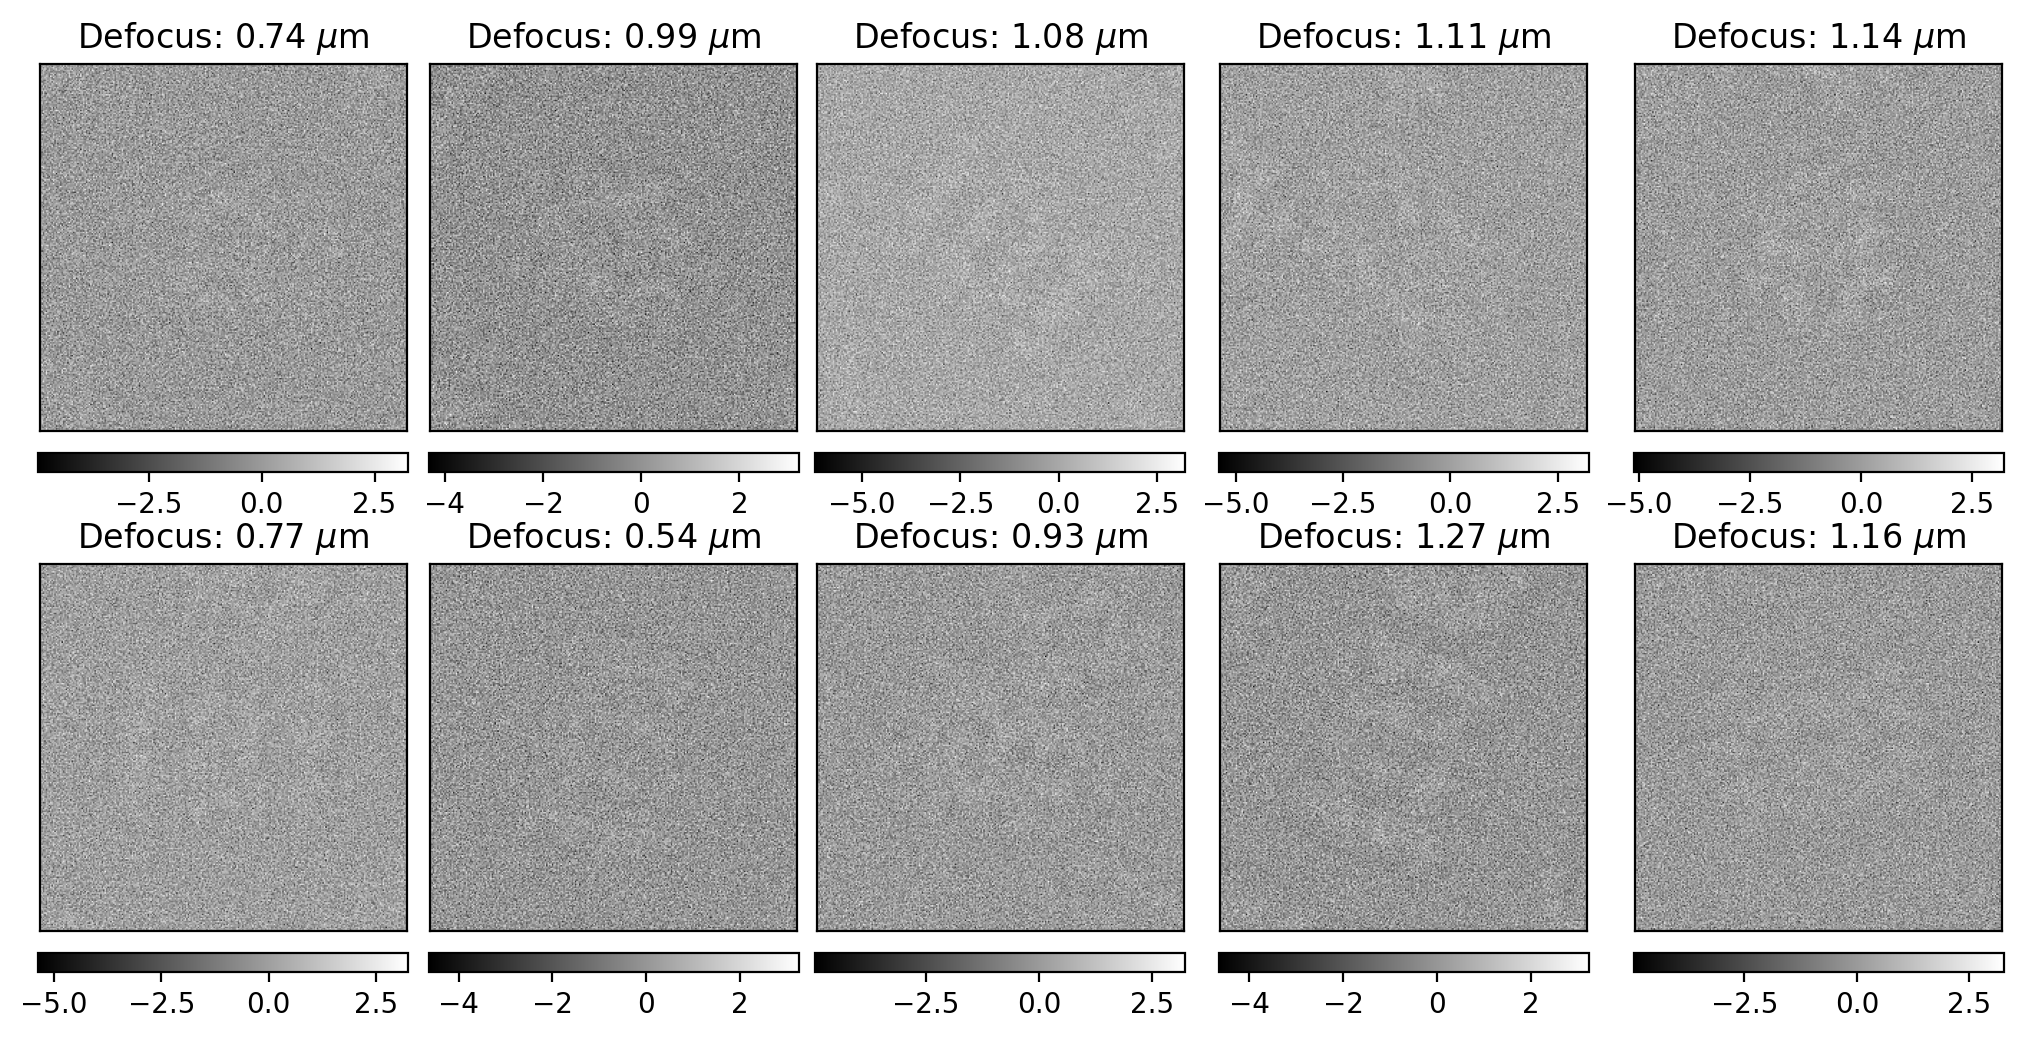

In [15]:
# normalize and flip sign
particles, means, stds = normalize_particles(images)
particles = -particles

fig, axes = plt.subplots(2, 5, dpi=200, constrained_layout=True, figsize=(10, 5))
for i, ax in enumerate(axes.ravel()):
    im = ax.imshow(particles[i], cmap="grey")
    ax.set(xticks=[], yticks=[])
    ax.set_title(f"Defocus: {ctf_params['dfu'][i] / 10000:.2f} $\mu$m")
    fig.colorbar(im, ax=ax, location="bottom")
plt.show()

In [16]:
# change folder paths for your use.
# folderpath = "/scratch/loh/joel/5MAC/simulated_data/"
# filename = "3000_256x256_20dose_nocrowd_and_ice_16sep2025"
# create_particle_starfile(
#     particles,
#     rotations=quaternions,
#     translations=translations,
#     ctf_params=ctf_params,
#     dx=dx,
#     energy=energy,
#     alpha=alpha,
#     filename=filename,
#     folderpath=folderpath,
# )